In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import square

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True

## Задание 1 — Вейвлет Морле

Временная область:
$$\psi(t) = e^{-\frac{t^2}{\alpha^2}} e^{i\omega_0 t}$$

Частотная область:
$$\hat{\psi}(\omega) = \alpha\sqrt{\pi}\, e^{-\alpha^2 \frac{(\omega - \omega_0)^2}{4}}$$

Основная частота ω₀ смещает центр фильтра в частотной области.
Чем больше ω₀ — тем выше частота осцилляций внутри гауссовой огибающей.

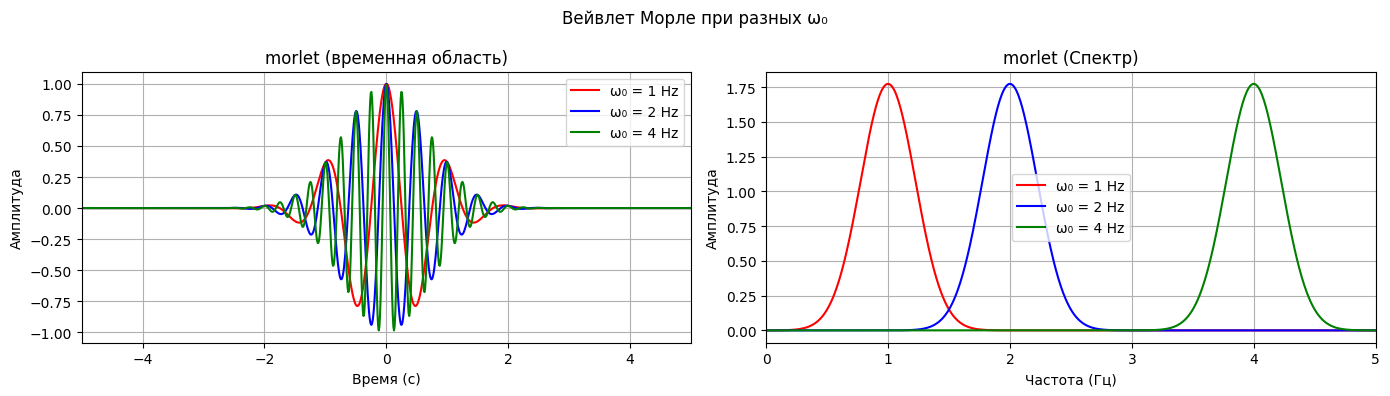

In [8]:
def morlet_time(t, alpha=1.0, omega0=2*np.pi):
    """Вейвлет Морле: нормированный по амплитуде."""
    gauss = np.exp(-t**2 / alpha**2)
    return (gauss * np.exp(1j * omega0 * t)) / np.max(np.abs(gauss))

def morlet_freq(omega, alpha=1.0, omega0=2*np.pi):
    """Вейвлет Морле в частотной области (аналитическая формула)."""
    return alpha * np.sqrt(np.pi) * np.exp(-alpha**2 * (omega - omega0)**2 / 4)

t  = np.linspace(-10, 10, 2000)
w  = np.linspace(0, 5, 1000) * 2 * np.pi

omega0_list = [2*np.pi*1, 2*np.pi*2, 2*np.pi*4]
colors      = ['red', 'blue', 'green']
labels      = ['ω₀ = 1 Hz', 'ω₀ = 2 Hz', 'ω₀ = 4 Hz']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Вейвлет Морле при разных ω₀')

for omega0, color, label in zip(omega0_list, colors, labels):
    psi_t = morlet_time(t, alpha=1.0, omega0=omega0)
    psi_w = morlet_freq(w, alpha=1.0, omega0=omega0)
    axes[0].plot(t, psi_t.real, color=color, label=label)
    axes[1].plot(w / (2*np.pi), psi_w, color=color, label=label)

axes[0].set_title('morlet (временная область)')
axes[0].set_xlabel('Время (с)')
axes[0].set_ylabel('Амплитуда')
axes[0].legend()
axes[0].set_xlim(-5, 5)

axes[1].set_title('morlet (Спектр)')
axes[1].set_xlabel('Частота (Гц)')
axes[1].set_ylabel('Амплитуда')
axes[1].legend()
axes[1].set_xlim(0, 5)

plt.tight_layout()
plt.show()

## Задание 2 — Вейвлет "Мексиканская шляпа"

Временная область:
$$\psi(t) = \left(1 - \frac{(t-t_0)^2}{\sigma^2}\right) e^{-\frac{(t-t_0)^2}{2\sigma^2}} \cdot e^{i\omega_0 t}$$

Частотная область:
$$\hat{\psi}(\omega) = (\omega - \omega_0)^2 e^{-\frac{(\omega-\omega_0)^2 \sigma^2}{2}}$$

Изменение ω₀ сдвигает пик спектра — управляет центральной частотой фильтра.

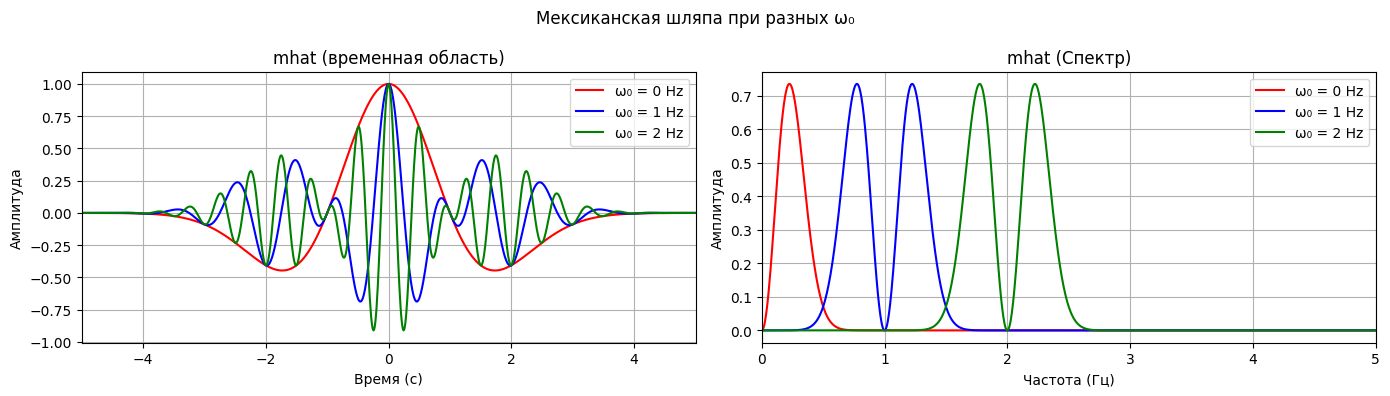

In [9]:
def mhat_time(t, sigma=1.0, t0=0.0, omega0=0.0):
    """Мексиканская шляпа: нормированная."""
    u = (t - t0) / sigma
    gauss = np.exp(-u**2 / 2)
    psi = (1 - u**2) * gauss * np.exp(1j * omega0 * t)
    return psi / np.max(np.abs(psi))

def mhat_freq(omega, sigma=1.0, omega0=0.0):
    """Вейвлет Мексиканская шляпа в частотной области."""
    d = omega - omega0
    return d**2 * np.exp(-d**2 * sigma**2 / 2)

omega0_list = [2*np.pi*0, 2*np.pi*1, 2*np.pi*2]
labels      = ['ω₀ = 0 Hz', 'ω₀ = 1 Hz', 'ω₀ = 2 Hz']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Мексиканская шляпа при разных ω₀')

for omega0, color, label in zip(omega0_list, colors, labels):
    psi_t = mhat_time(t, sigma=1.0, omega0=omega0)
    psi_w = mhat_freq(w, sigma=1.0, omega0=omega0)
    axes[0].plot(t, psi_t.real, color=color, label=label)
    axes[1].plot(w / (2*np.pi), np.abs(psi_w), color=color, label=label)

axes[0].set_title('mhat (временная область)')
axes[0].set_xlabel('Время (с)')
axes[0].set_ylabel('Амплитуда')
axes[0].legend()
axes[0].set_xlim(-5, 5)

axes[1].set_title('mhat (Спектр)')
axes[1].set_xlabel('Частота (Гц)')
axes[1].set_ylabel('Амплитуда')
axes[1].legend()
axes[1].set_xlim(0, 5)

plt.tight_layout()
plt.show()

## Задание 3 — Вейвлет Хаара

Временная область:
$$\psi(t) = \begin{cases} 1, & 0 \leq t < 0.5 \\ -1, & 0.5 \leq t < 1 \\ 0, & \text{иначе} \end{cases}$$

Частотная область:
$$\hat{\psi}(\omega) = 2i\sin\left(\frac{\omega}{2}\right)e^{-i\omega/2}$$

Масштабирование меняет центральную частоту:
$$\psi_a(t) = \frac{1}{\sqrt{a}}\psi\left(\frac{t}{a}\right), \quad \hat{\psi}_a(\omega) = \sqrt{a}\,\hat{\psi}(a\omega)$$

При `a < 1` — вейвлет сжимается → частота растёт. При `a > 1` — расширяется → частота падает.

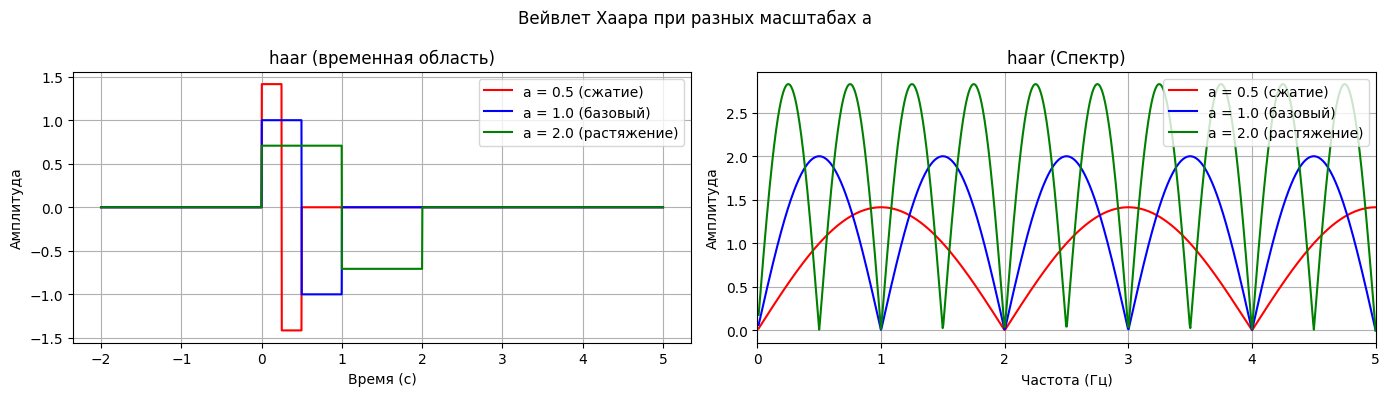

In [10]:
def haar_time(t, a=1.0):
    """Вейвлет Хаара во временной области с масштабом a."""
    t_scaled = t / a
    psi = np.zeros_like(t)
    psi[(t_scaled >= 0)   & (t_scaled < 0.5)] =  1.0
    psi[(t_scaled >= 0.5) & (t_scaled < 1.0)] = -1.0
    return psi / np.sqrt(a)

def haar_freq(omega, a=1.0):
    """Вейвлет Хаара в частотной области с масштабом a."""
    aw = a * omega
    return np.sqrt(a) * 2j * np.sin(aw / 2) * np.exp(-1j * aw / 2)

t_haar = np.linspace(-2, 5, 2000)
w_haar = np.linspace(0.01, 5, 1000) * 2 * np.pi

a_list  = [0.5, 1.0, 2.0]
labels3 = ['a = 0.5 (сжатие)', 'a = 1.0 (базовый)', 'a = 2.0 (растяжение)']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Вейвлет Хаара при разных масштабах a')

for a, color, label in zip(a_list, colors, labels3):
    psi_t = haar_time(t_haar, a=a)
    psi_w = haar_freq(w_haar, a=a)
    axes[0].plot(t_haar, psi_t, color=color, label=label)
    axes[1].plot(w_haar / (2*np.pi), np.abs(psi_w), color=color, label=label)

axes[0].set_title('haar (временная область)')
axes[0].set_xlabel('Время (с)')
axes[0].set_ylabel('Амплитуда')
axes[0].legend()

axes[1].set_title('haar (Спектр)')
axes[1].set_xlabel('Частота (Гц)')
axes[1].set_ylabel('Амплитуда')
axes[1].legend()
axes[1].set_xlim(0, 5)

plt.tight_layout()
plt.show()

## Задание 4 — Фильтрация сигнала тремя вейвлетами

Свёртка сигнала с вейвлетами Морле, Мексиканской шляпой и Хаара.

**(а)** Сигнал с тремя выделенными частотами  
**(б)** Прямоугольный меандр

Сравниваем качество фильтрации и сильные/слабые стороны каждого вейвлета.

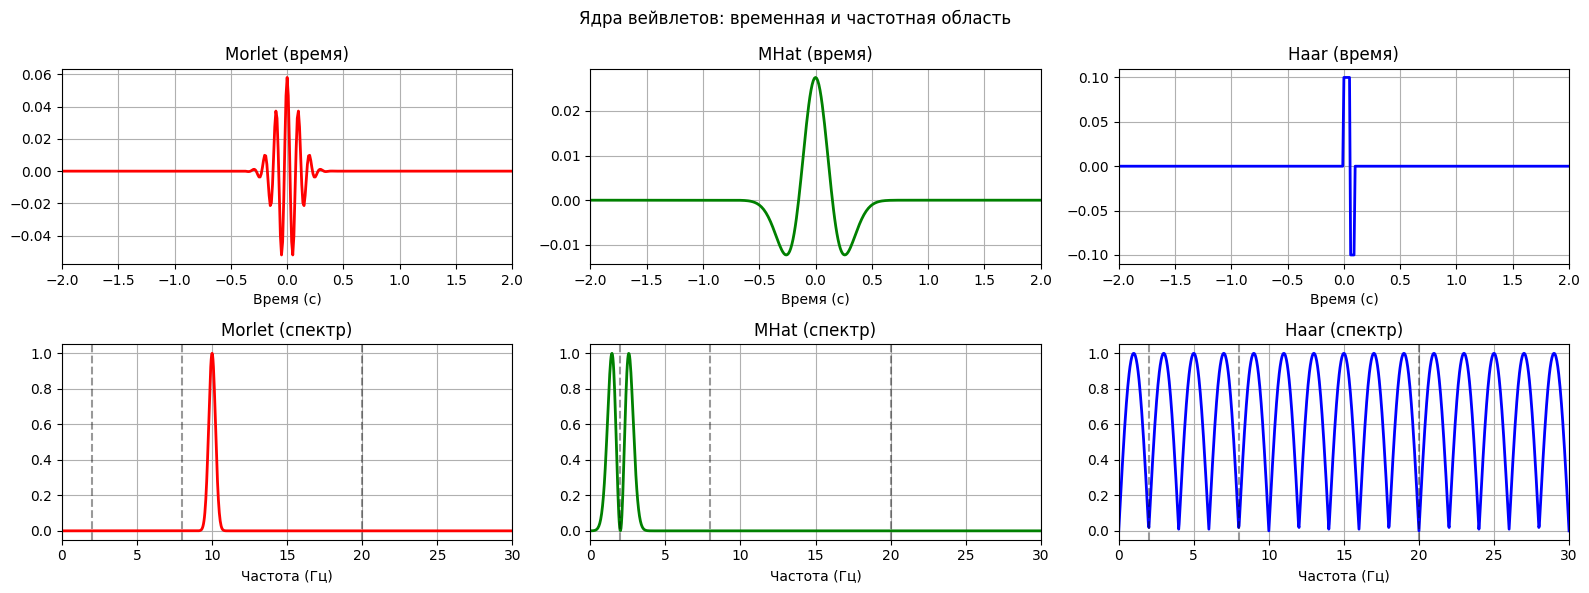

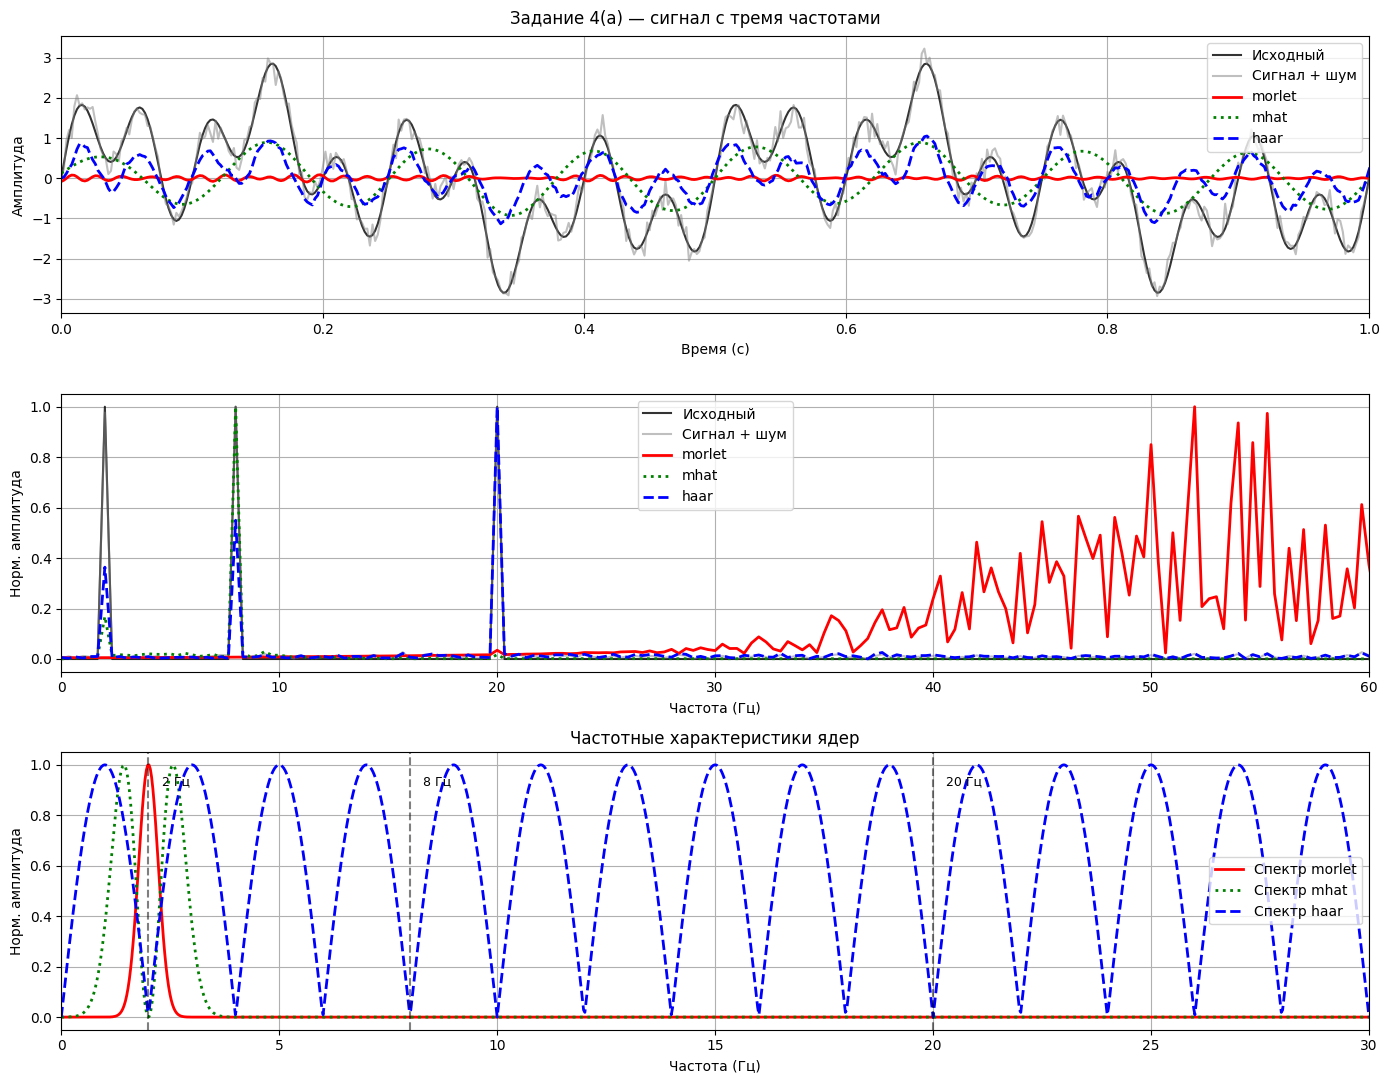

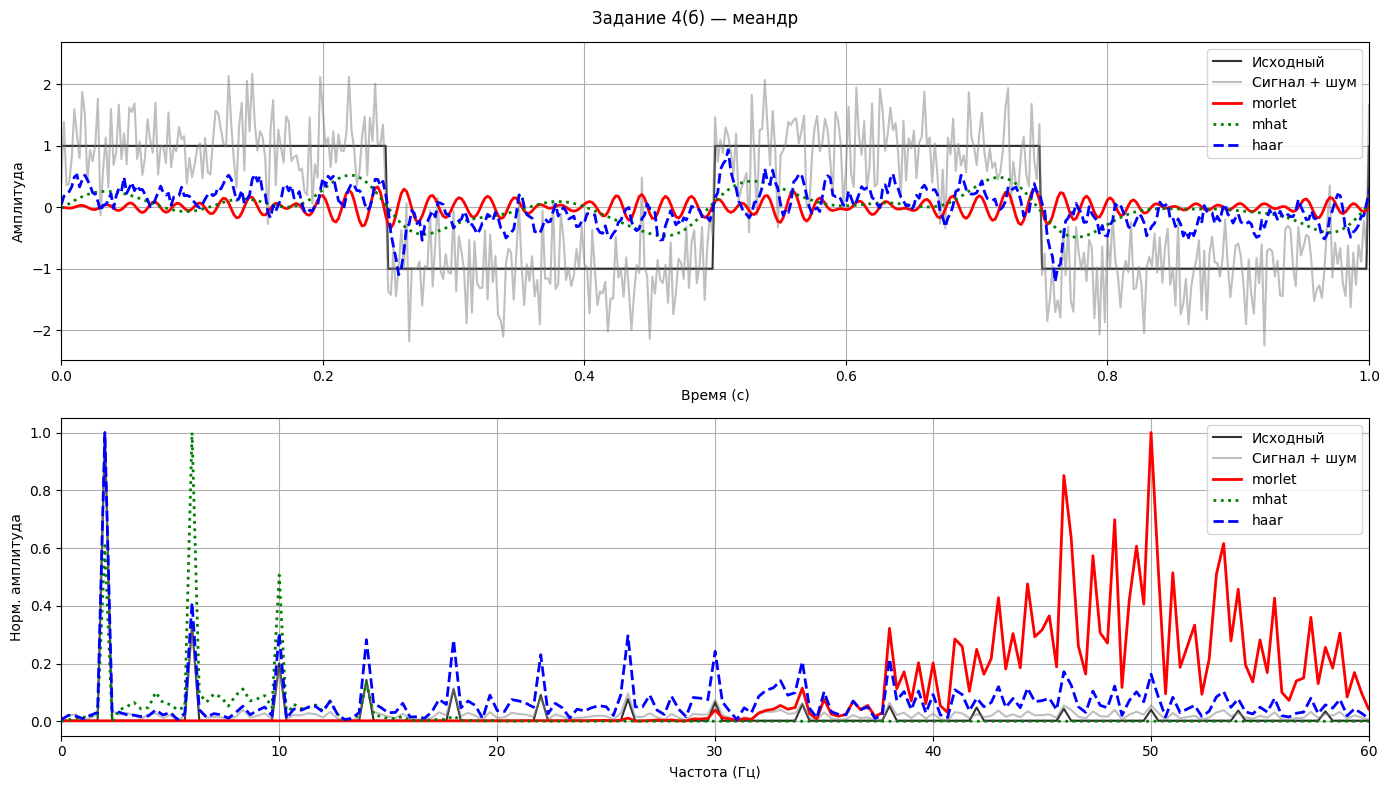

In [ ]:
fs4 = 500
T4 = 3.0
t4w = np.linspace(0, T4, int(fs4 * T4), endpoint=False)

# (а) сигнал с 3 частотами + шум
sig_a = (np.sin(2*np.pi*2*t4w) +
         np.sin(2*np.pi*8*t4w) +
         np.sin(2*np.pi*20*t4w))
noisy_a = sig_a + 0.2 * np.random.randn(len(t4w))

# вейвлеты
t_ker  = np.linspace(-5, 5, 1001)
omega0_morlet = 2 * np.pi * 10

ker_morlet = morlet_time(t_ker, alpha=0.15, omega0=2*np.pi*10).real
ker_mhat   = mhat_time(t_ker, sigma=0.15, omega0=0).real
ker_haar   = haar_time(t_ker, a=0.1)

ker_morlet /= np.sum(np.abs(ker_morlet))
ker_mhat   /= np.sum(np.abs(ker_mhat))
ker_haar   /= np.sum(np.abs(ker_haar))

# свёртки
conv_morlet = np.convolve(noisy_a, ker_morlet, mode='same')
conv_mhat   = np.convolve(noisy_a, ker_mhat,   mode='same')
conv_haar   = np.convolve(noisy_a, ker_haar,   mode='same')

# спектры сигналов
freqs4 = np.fft.rfftfreq(len(t4w), d=1/fs4)

def norm_spectrum(sig):
    """Нормированный спектр сигнала."""
    S = np.abs(np.fft.rfft(sig))
    return S / S.max()

# аналитические спектры ядер
w_plot = np.linspace(0, 30, 1000) * 2 * np.pi
f_plot = w_plot / (2 * np.pi)

def morlet_freq_kernel(w, alpha=1.0, omega0=2*np.pi*2):
    """Аналитический спектр Морле."""
    K = np.exp(-alpha**2 * (w - omega0)**2 / 4)
    return K / K.max()

def mhat_freq_kernel(w, sigma=0.4, omega0=2*np.pi*2):
    """Аналитический спектр МШ."""
    d = w - omega0
    K = d**2 * np.exp(-d**2 * sigma**2 / 2)
    return K / K.max()

def haar_freq_kernel(w, a=0.5):
    """Аналитический спектр Хаара."""
    aw = np.where(w == 0, 1e-10, a * w)
    K  = np.abs(2j * np.sin(aw / 2) * np.exp(-1j * aw / 2))
    return K / K.max()

freq_fns = [
    lambda w: morlet_freq_kernel(w, alpha=1.0, omega0=omega0),
    lambda w: mhat_freq_kernel(w,   sigma=0.4, omega0=omega0),
    lambda w: haar_freq_kernel(w,   a=0.5),
]

# --- вейвлеты и их спектры ---
fig, axes = plt.subplots(2, 3, figsize=(16, 6))
fig.suptitle('Ядра вейвлетов: временная и частотная область')

ker_list   = [ker_morlet, ker_mhat, ker_haar]
ker_names  = ['Morlet', 'MHat', 'Haar']
ker_colors = ['red', 'green', 'blue']

for i, (ker, name, color, freq_fn) in enumerate(zip(ker_list, ker_names, ker_colors, freq_fns)):
    axes[0, i].plot(t_ker, ker, color=color, lw=2)
    axes[0, i].set_title(f'{name} (время)')
    axes[0, i].set_xlabel('Время (с)')
    axes[0, i].set_xlim(-2, 2)

    axes[1, i].plot(f_plot, freq_fn(w_plot), color=color, lw=2)
    axes[1, i].set_title(f'{name} (спектр)')
    axes[1, i].set_xlabel('Частота (Гц)')
    axes[1, i].set_xlim(0, 30)
    for f in [2, 8, 20]:
        axes[1, i].axvline(f, color='black', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# --- (а) сигнал с тремя частотами ---
fig, axes = plt.subplots(3, 1, figsize=(14, 11))
fig.suptitle('Задание 4(а) — сигнал с тремя частотами')

axes[0].plot(t4w, sig_a,        color='black', lw=1.5, alpha=0.8, label='Исходный')
axes[0].plot(t4w, noisy_a,      color='gray',  alpha=0.5,         label='Сигнал + шум')
axes[0].plot(t4w, conv_morlet,  color='red',   lw=2,              label='morlet')
axes[0].plot(t4w, conv_mhat,    color='green', lw=2, linestyle='dotted', label='mhat')
axes[0].plot(t4w, conv_haar,    color='blue',  lw=2, linestyle='dashed', label='haar')
axes[0].set_xlabel('Время (с)')
axes[0].set_ylabel('Амплитуда')
axes[0].set_xlim(0, 1)
axes[0].legend()

axes[1].plot(freqs4, norm_spectrum(sig_a),        color='black', lw=1.5, alpha=0.8, label='Исходный')
axes[1].plot(freqs4, norm_spectrum(noisy_a),      color='gray',  alpha=0.5,         label='Сигнал + шум')
axes[1].plot(freqs4, norm_spectrum(conv_morlet),  color='red',   lw=2,              label='morlet')
axes[1].plot(freqs4, norm_spectrum(conv_mhat),    color='green', lw=2, linestyle='dotted', label='mhat')
axes[1].plot(freqs4, norm_spectrum(conv_haar),    color='blue',  lw=2, linestyle='dashed', label='haar')
axes[1].set_xlabel('Частота (Гц)')
axes[1].set_ylabel('Норм. амплитуда')
axes[1].set_xlim(0, 60)
axes[1].legend()

axes[2].plot(f_plot, morlet_freq_kernel(w_plot), color='red',   lw=2,              label='Спектр morlet')
axes[2].plot(f_plot, mhat_freq_kernel(w_plot),   color='green', lw=2, linestyle='dotted', label='Спектр mhat')
axes[2].plot(f_plot, haar_freq_kernel(w_plot),   color='blue',  lw=2, linestyle='dashed', label='Спектр haar')
for f in [2, 8, 20]:
    axes[2].axvline(f, color='black', linestyle='--', alpha=0.5)
    axes[2].text(f + 0.3, 0.92, f'{f} Гц', fontsize=9)
axes[2].set_xlabel('Частота (Гц)')
axes[2].set_ylabel('Норм. амплитуда')
axes[2].set_xlim(0, 30)
axes[2].set_title('Частотные характеристики ядер')
axes[2].legend()

plt.tight_layout()
plt.show()

# --- (б) меандр ---
from scipy.signal import square as sq
sig_b   = sq(2 * np.pi * 2 * t4w)
noisy_b = sig_b + 0.5 * np.random.randn(len(t4w))

conv_morlet_b = np.convolve(noisy_b, ker_morlet, mode='same')
conv_mhat_b   = np.convolve(noisy_b, ker_mhat,   mode='same')
conv_haar_b   = np.convolve(noisy_b, ker_haar,   mode='same')

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Задание 4(б) — меандр')

axes[0].plot(t4w, sig_b,         color='black', lw=1.5, alpha=0.8, label='Исходный')
axes[0].plot(t4w, noisy_b,       color='gray',  alpha=0.5,         label='Сигнал + шум')
axes[0].plot(t4w, conv_morlet_b, color='red',   lw=2,              label='morlet')
axes[0].plot(t4w, conv_mhat_b,   color='green', lw=2, linestyle='dotted', label='mhat')
axes[0].plot(t4w, conv_haar_b,   color='blue',  lw=2, linestyle='dashed', label='haar')
axes[0].set_xlabel('Время (с)')
axes[0].set_ylabel('Амплитуда')
axes[0].set_xlim(0, 1)
axes[0].legend()

axes[1].plot(freqs4, norm_spectrum(sig_b),         color='black', lw=1.5, alpha=0.8, label='Исходный')
axes[1].plot(freqs4, norm_spectrum(noisy_b),       color='gray',  alpha=0.5,         label='Сигнал + шум')
axes[1].plot(freqs4, norm_spectrum(conv_morlet_b), color='red',   lw=2,              label='morlet')
axes[1].plot(freqs4, norm_spectrum(conv_mhat_b),   color='green', lw=2, linestyle='dotted', label='mhat')
axes[1].plot(freqs4, norm_spectrum(conv_haar_b),   color='blue',  lw=2, linestyle='dashed', label='haar')
axes[1].set_xlabel('Частота (Гц)')
axes[1].set_ylabel('Норм. амплитуда')
axes[1].set_xlim(0, 60)
axes[1].legend()

plt.tight_layout()
plt.show()

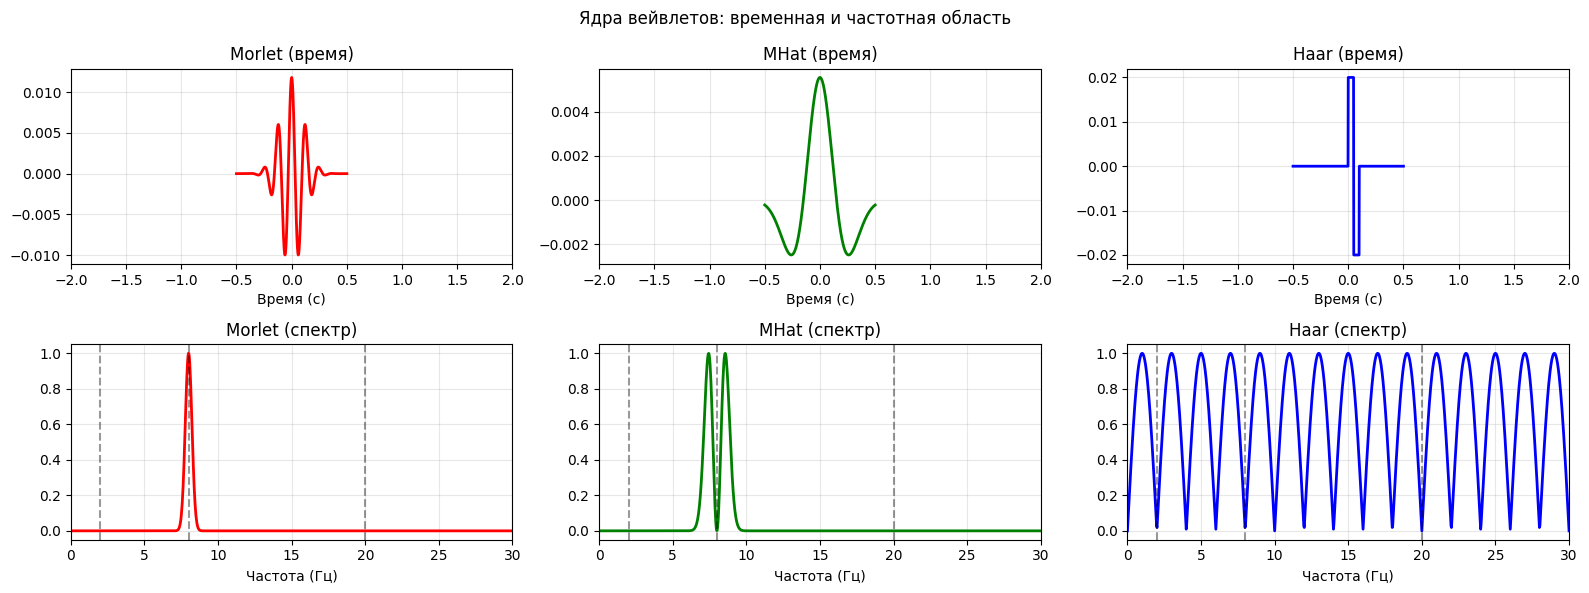

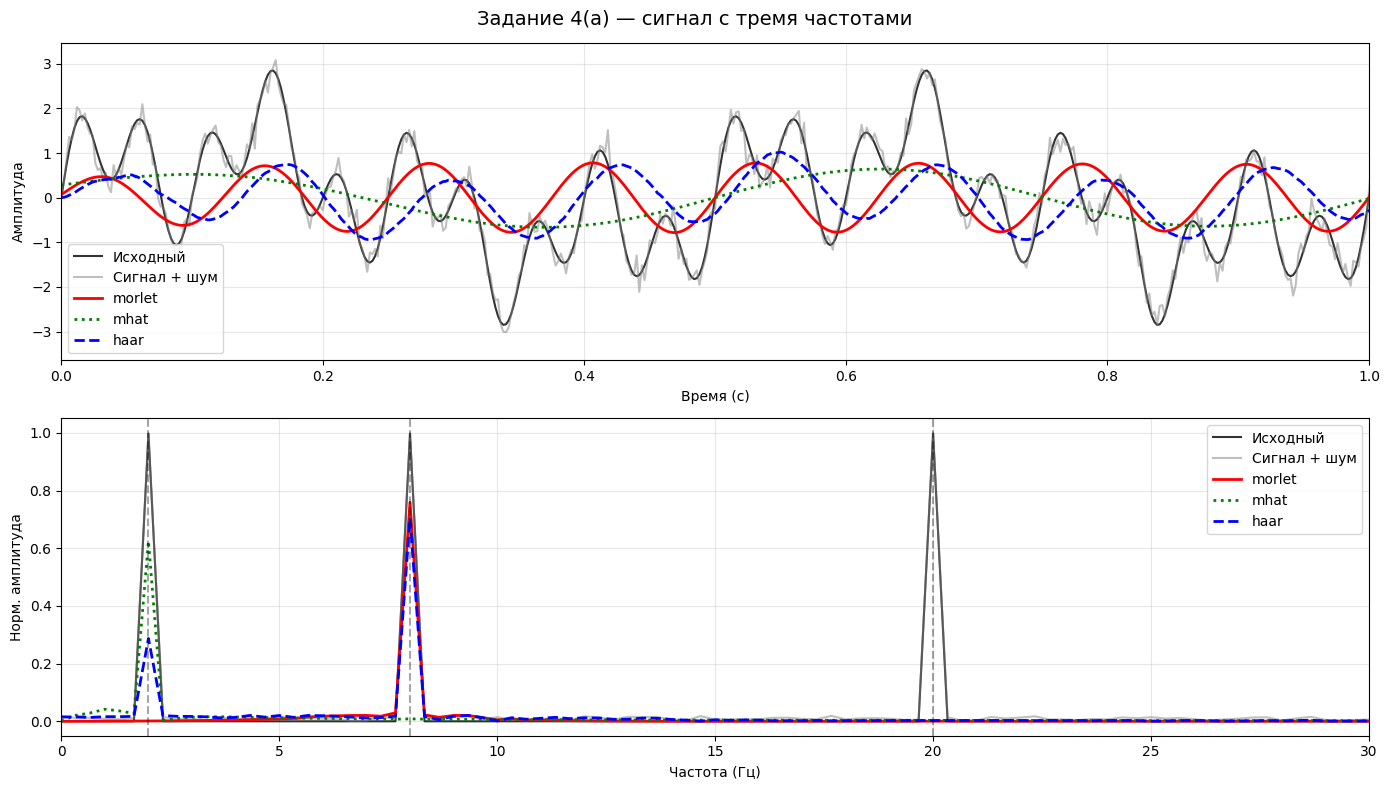

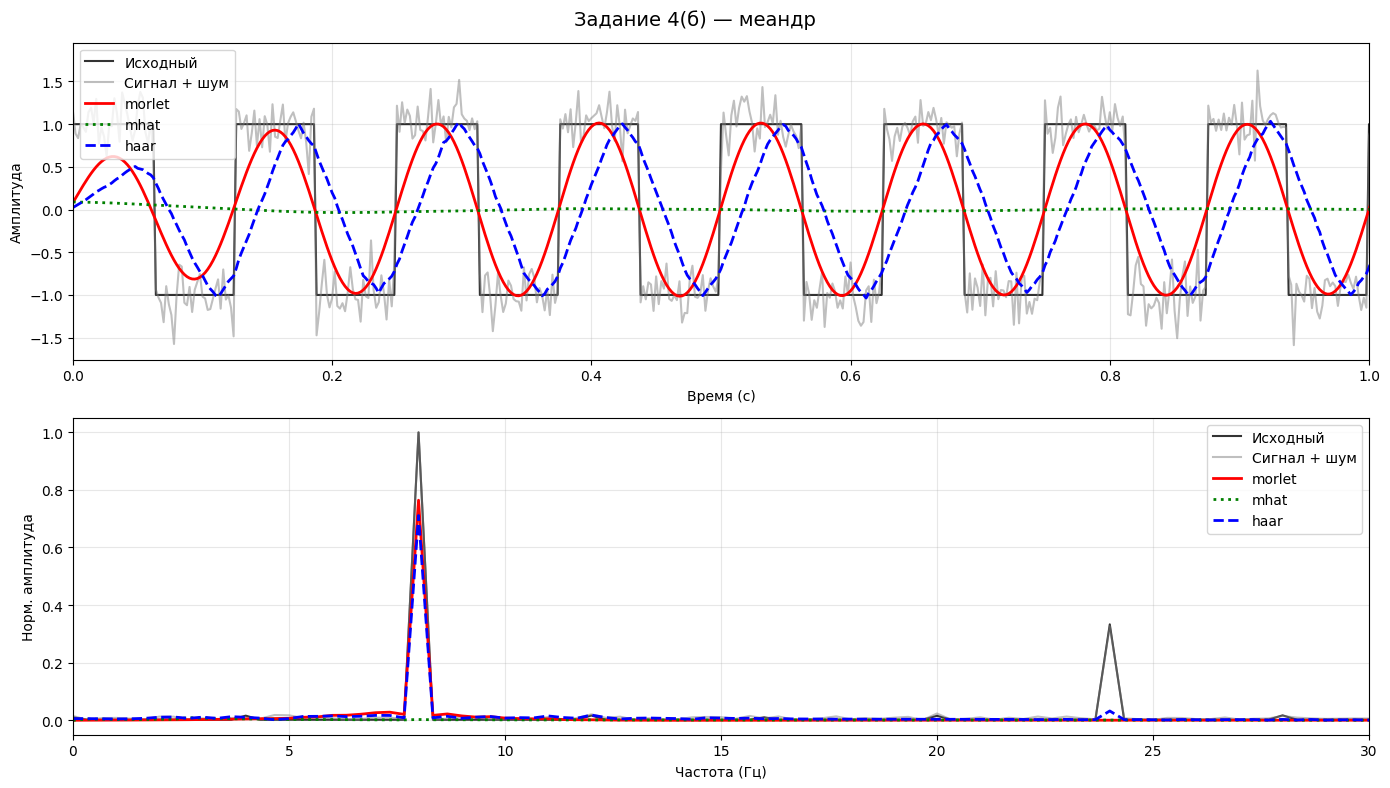

In [25]:
np.random.seed(42)

fs4 = 500
T4 = 3.0
t4w = np.linspace(0, T4, int(fs4 * T4), endpoint=False)


target_freq = 8.0
omega0 = 2 * np.pi * target_freq

# Параметры ядер
alpha_morlet = 0.15
sigma_mhat   = 0.15
a_haar       = 0.10

# Сетка для ядер
dt = 1 / fs4
t_ker = np.arange(-0.5, 0.5 + dt, dt)
# =========================================================
# 1. ВЕЙВЛЕТЫ
# =========================================================

def morlet_time(t, alpha=0.15, omega0=2*np.pi*8):
    """
    Вейвлет Морле:
    psi(t) = exp(-t^2 / alpha^2) * exp(i * omega0 * t)
    """
    return np.exp(-(t**2) / (alpha**2)) * np.exp(1j * omega0 * t)


def mhat_time(t, sigma=0.15, omega0=0.0, t0=0.0):
    """
    Мексиканская шляпа.
    По умолчанию берём классическую форму с omega0 = 0.
    """
    u = t - t0
    return (1 - (u**2) / (sigma**2)) * np.exp(-(u**2) / (2 * sigma**2)) * np.exp(1j * omega0 * t)


def haar_time(t, a=0.10):
    """
    Масштабированный вейвлет Хаара:
        psi_a(t) = (1 / sqrt(a)) * psi(t / a)
    где
        psi =  1,  0 <= t < 0.5
              -1,  0.5 <= t < 1
               0,  иначе
    """
    t_scaled = t / a
    psi = np.zeros_like(t, dtype=float)
    psi[(t_scaled >= 0.0) & (t_scaled < 0.5)] = 1.0
    psi[(t_scaled >= 0.5) & (t_scaled < 1.0)] = -1.0
    return psi / np.sqrt(a)

# =========================================================
# 2. ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# =========================================================

def normalize_kernel(kernel):
    """
    Нормировка ядра для сравнимых откликов.
    """
    s = np.sum(np.abs(kernel))
    return kernel if s == 0 else kernel / s


def kernel_spectrum_from_fft(kernel, fs, n_fft=8192):
    """
    Спектр считаем FFT от того же самого ядра, которое реально участвует в свёртке.
    Это лучше, чем рисовать отдельную аналитическую формулу с другими параметрами.
    """
    k = np.fft.ifftshift(kernel)
    freqs = np.fft.rfftfreq(n_fft, d=1/fs)
    K = np.abs(np.fft.rfft(k, n=n_fft))
    if K.max() > 0:
        K = K / K.max()
    return freqs, K


def raw_spectrum(sig):
    """
    Ненормированный спектр сигнала.
    """
    return np.abs(np.fft.rfft(sig))


def normalize_group(*spectra):
    """
    Нормировка всех спектров на один общий максимум,
    чтобы слабый хвост не становился визуально 'главным'.
    """
    common_max = max(np.max(s) for s in spectra)
    if common_max == 0:
        return spectra
    return [s / common_max for s in spectra]

# =========================================================
# 3. ЯДРА ВЕЙВЛЕТОВ
# =========================================================

# Берём вещественные формы для наглядных графиков свёртки
ker_morlet = np.real(morlet_time(t_ker, alpha=alpha_morlet, omega0=omega0))
ker_mhat   = np.real(mhat_time(t_ker, sigma=sigma_mhat, omega0=0.0))
ker_haar   = haar_time(t_ker, a=a_haar)

ker_morlet = normalize_kernel(ker_morlet)
ker_mhat   = normalize_kernel(ker_mhat)
ker_haar   = normalize_kernel(ker_haar)

# Спектры тех же самых ядер
freqs_k, K_morlet = kernel_spectrum_from_fft(ker_morlet, fs4)
_,       K_mhat   = kernel_spectrum_from_fft(ker_mhat,   fs4)
_,       K_haar   = kernel_spectrum_from_fft(ker_haar,   fs4)

# =========================================================
# 4. ФИГУРА 1: ЯДРА И ИХ СПЕКТРЫ
# =========================================================

w_plot = np.linspace(0, 30, 1000) * 2 * np.pi
f_plot = w_plot / (2 * np.pi)

omega0_vis = 2 * np.pi * 8

def morlet_freq_kernel(w, alpha=1.0, omega0=2*np.pi*2):
    """Аналитический спектр Морле."""
    K = np.exp(-alpha**2 * (w - omega0)**2 / 4)
    return K / K.max()

def mhat_freq_kernel(w, sigma=0.4, omega0=2*np.pi*2):
    """Аналитический спектр Mexican Hat."""
    d = w - omega0
    K = d**2 * np.exp(-d**2 * sigma**2 / 2)
    return K / K.max()

def haar_freq_kernel(w, a=0.5):
    """Аналитический спектр Хаара"""
    aw = np.where(w == 0, 1e-10, a * w)
    K = np.abs(2j * np.sin(aw / 2) * np.exp(-1j * aw / 2))
    return K / K.max()

freq_fns = [
    lambda w: morlet_freq_kernel(w, alpha=1.0, omega0=omega0_vis),
    lambda w: mhat_freq_kernel(w,   sigma=0.4, omega0=omega0_vis),
    lambda w: haar_freq_kernel(w,   a=0.5),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 6))
fig.suptitle('Ядра вейвлетов: временная и частотная область')

ker_list   = [ker_morlet, ker_mhat, ker_haar]
ker_names  = ['Morlet', 'MHat', 'Haar']
ker_colors = ['red', 'green', 'blue']

for i, (ker, name, color, freq_fn) in enumerate(zip(ker_list, ker_names, ker_colors, freq_fns)):
    axes[0, i].plot(t_ker, ker, color=color, lw=2)
    axes[0, i].set_title(f'{name} (время)')
    axes[0, i].set_xlabel('Время (с)')
    axes[0, i].set_xlim(-2, 2)
    axes[0, i].grid(True, alpha=0.3)

    axes[1, i].plot(f_plot, freq_fn(w_plot), color=color, lw=2)
    axes[1, i].set_title(f'{name} (спектр)')
    axes[1, i].set_xlabel('Частота (Гц)')
    axes[1, i].set_xlim(0, 30)
    for f in [2, 8, 20]:
        axes[1, i].axvline(f, color='black', linestyle='--', alpha=0.4)
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =========================================================
# 5. ЗАДАНИЕ 4(А): СИГНАЛ С 3 ЧАСТОТАМИ
# =========================================================

sig_a = (
    np.sin(2*np.pi*2*t4w) +
    np.sin(2*np.pi*8*t4w) +
    np.sin(2*np.pi*20*t4w)
)
noisy_a = sig_a + 0.2 * np.random.randn(len(t4w))

conv_morlet_a = np.convolve(noisy_a, ker_morlet, mode='same')
conv_mhat_a   = np.convolve(noisy_a, ker_mhat,   mode='same')
conv_haar_a   = np.convolve(noisy_a, ker_haar,   mode='same')

freqs_a = np.fft.rfftfreq(len(t4w), d=1/fs4)

S_sig_a         = raw_spectrum(sig_a)
S_noisy_a       = raw_spectrum(noisy_a)
S_conv_morlet_a = raw_spectrum(conv_morlet_a)
S_conv_mhat_a   = raw_spectrum(conv_mhat_a)
S_conv_haar_a   = raw_spectrum(conv_haar_a)

S_sig_a, S_noisy_a, S_conv_morlet_a, S_conv_mhat_a, S_conv_haar_a = normalize_group(
    S_sig_a, S_noisy_a, S_conv_morlet_a, S_conv_mhat_a, S_conv_haar_a
)

fig1, axes1 = plt.subplots(2, 1, figsize=(14, 8))
fig1.suptitle('Задание 4(а) — сигнал с тремя частотами', fontsize=14)

# Временная область
axes1[0].plot(t4w, sig_a,          color='black', lw=1.5, alpha=0.8, label='Исходный')
axes1[0].plot(t4w, noisy_a,        color='gray',  alpha=0.5,         label='Сигнал + шум')
axes1[0].plot(t4w, conv_morlet_a,  color='red',   lw=2,              label='morlet')
axes1[0].plot(t4w, conv_mhat_a,    color='green', lw=2, linestyle='dotted', label='mhat')
axes1[0].plot(t4w, conv_haar_a,    color='blue',  lw=2, linestyle='dashed', label='haar')
axes1[0].set_xlabel('Время (с)')
axes1[0].set_ylabel('Амплитуда')
axes1[0].set_xlim(0, 1)
axes1[0].grid(True, alpha=0.3)
axes1[0].legend()

# Частотная область
axes1[1].plot(freqs_a, S_sig_a,          color='black', lw=1.5, alpha=0.8, label='Исходный')
axes1[1].plot(freqs_a, S_noisy_a,        color='gray',  alpha=0.5,         label='Сигнал + шум')
axes1[1].plot(freqs_a, S_conv_morlet_a,  color='red',   lw=2,              label='morlet')
axes1[1].plot(freqs_a, S_conv_mhat_a,    color='green', lw=2, linestyle='dotted', label='mhat')
axes1[1].plot(freqs_a, S_conv_haar_a,    color='blue',  lw=2, linestyle='dashed', label='haar')

for f in [2, 8, 20]:
    axes1[1].axvline(f, color='black', linestyle='--', alpha=0.35)

axes1[1].set_xlabel('Частота (Гц)')
axes1[1].set_ylabel('Норм. амплитуда')
axes1[1].set_xlim(0, 30)
axes1[1].grid(True, alpha=0.3)
axes1[1].legend()

plt.tight_layout()
plt.show()

# =========================================================
# 6. ЗАДАНИЕ 4(Б): МЕАНДР
# =========================================================

sig_b   = square(2 * np.pi * 8 * t4w)
noisy_b = sig_b + 0.2 * np.random.randn(len(t4w))

conv_morlet_b = np.convolve(noisy_b, ker_morlet, mode='same')
conv_mhat_b   = np.convolve(noisy_b, ker_mhat,   mode='same')
conv_haar_b   = np.convolve(noisy_b, ker_haar,   mode='same')

freqs_b = np.fft.rfftfreq(len(t4w), d=1/fs4)

S_sig_b         = raw_spectrum(sig_b)
S_noisy_b       = raw_spectrum(noisy_b)
S_conv_morlet_b = raw_spectrum(conv_morlet_b)
S_conv_mhat_b   = raw_spectrum(conv_mhat_b)
S_conv_haar_b   = raw_spectrum(conv_haar_b)

S_sig_b, S_noisy_b, S_conv_morlet_b, S_conv_mhat_b, S_conv_haar_b = normalize_group(
    S_sig_b, S_noisy_b, S_conv_morlet_b, S_conv_mhat_b, S_conv_haar_b
)

fig2, axes2 = plt.subplots(2, 1, figsize=(14, 8))
fig2.suptitle('Задание 4(б) — меандр', fontsize=14)

# Временная область
axes2[0].plot(t4w, sig_b,          color='black', lw=1.5, alpha=0.8, label='Исходный')
axes2[0].plot(t4w, noisy_b,        color='gray',  alpha=0.5,         label='Сигнал + шум')
axes2[0].plot(t4w, conv_morlet_b,  color='red',   lw=2,              label='morlet')
axes2[0].plot(t4w, conv_mhat_b,    color='green', lw=2, linestyle='dotted', label='mhat')
axes2[0].plot(t4w, conv_haar_b,    color='blue',  lw=2, linestyle='dashed', label='haar')
axes2[0].set_xlabel('Время (с)')
axes2[0].set_ylabel('Амплитуда')
axes2[0].set_xlim(0, 1)
axes2[0].grid(True, alpha=0.3)
axes2[0].legend()

# Частотная область
axes2[1].plot(freqs_b, S_sig_b,          color='black', lw=1.5, alpha=0.8, label='Исходный')
axes2[1].plot(freqs_b, S_noisy_b,        color='gray',  alpha=0.5,         label='Сигнал + шум')
axes2[1].plot(freqs_b, S_conv_morlet_b,  color='red',   lw=2,              label='morlet')
axes2[1].plot(freqs_b, S_conv_mhat_b,    color='green', lw=2, linestyle='dotted', label='mhat')
axes2[1].plot(freqs_b, S_conv_haar_b,    color='blue',  lw=2, linestyle='dashed', label='haar')
axes2[1].set_xlabel('Частота (Гц)')
axes2[1].set_ylabel('Норм. амплитуда')
axes2[1].set_xlim(0, 30)
axes2[1].grid(True, alpha=0.3)
axes2[1].legend()

plt.tight_layout()
plt.show()

## Задание 5 — Спектрограмма через вейвлет Морле

Сигнал с меняющейся частотой (чирп): частота растёт со временем.
Спектрограмма строится как матрица мощности |W(t, f)|² — свёртка сигнала
с масштабированным вейвлетом Морле для каждой частоты.

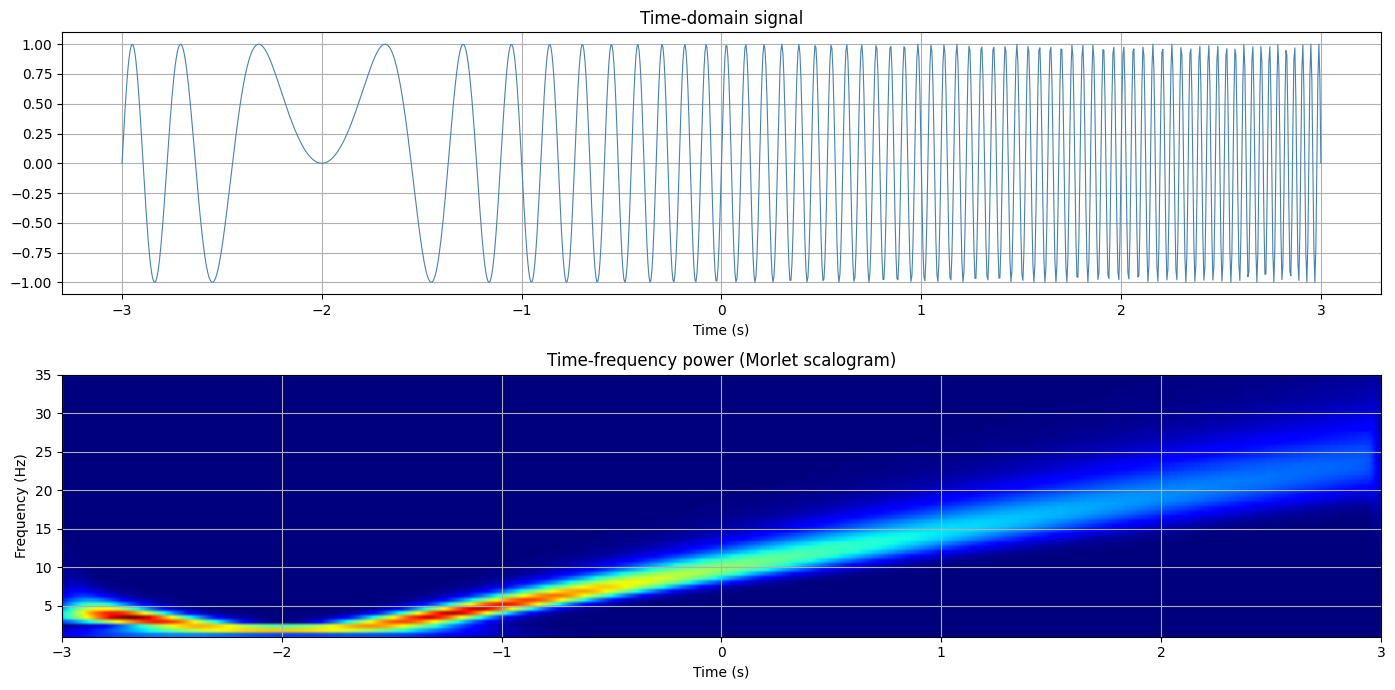

In [6]:
fs5  = 200
T5   = 6.0
t5   = np.linspace(-T5/2, T5/2, int(fs5 * T5))

# чирп: частота меняется от 10 до 25 Hz
chirp_f = 10 + 7.5 * t5 / T5 * 2
chirp   = np.sin(2 * np.pi * chirp_f * t5)

freqs5w = np.linspace(1, 35, 60)
dt5     = t5[1] - t5[0]

def morlet_scalogram(signal, t, freqs, fs, alpha=1.0):
    """Скалограмма через свёртку с вейвлетом Морле для каждой частоты."""
    W = np.zeros((len(freqs), len(signal)), dtype=complex)
    for i, f in enumerate(freqs):
        omega0 = 2 * np.pi * f
        n_ker  = min(int(8 * fs / f) + 1, len(signal))  # ядро не длиннее сигнала
        t_ker  = np.linspace(-4/f, 4/f, n_ker)
        kernel = np.exp(-t_ker**2 * f**2) * np.exp(1j * omega0 * t_ker)
        kernel /= np.sqrt(np.sum(np.abs(kernel)**2))
        conv   = np.convolve(signal, kernel, mode='same')
        W[i]   = conv[:len(signal)]  # обрезаем на всякий случай
    return W

W = morlet_scalogram(chirp, t5, freqs5w, fs5)
power = np.abs(W)**2

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
axes[0].plot(t5, chirp, color='steelblue', lw=0.8)
axes[0].set_title('Time-domain signal')
axes[0].set_xlabel('Time (s)')

axes[1].imshow(power, aspect='auto', origin='lower',
               extent=[t5[0], t5[-1], freqs5w[0], freqs5w[-1]],
               cmap='jet')
axes[1].set_title('Time-frequency power (Morlet scalogram)')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Frequency (Hz)')

plt.tight_layout()
plt.show()

## Задание 6 — Спектрограммы аудиофайла

Загружаем wav-файл и строим три спектрограммы:
- **Морле** — хорошее частотное разрешение, гладкий спектр
- **Хаар** — острое временное разрешение, видны резкие переходы
- **Мексиканская шляпа** — промежуточный вариант

Для проверки: нота "ля" первой октавы → основная гармоника 440 Гц.

/tmp/ipykernel_123882/3264575988.py:7: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr, audio = wavfile.read(WAV_PATH)


Файл загружен: sr=44100 Hz, длина=1.00 с
Считаем скалограммы...
Готово!


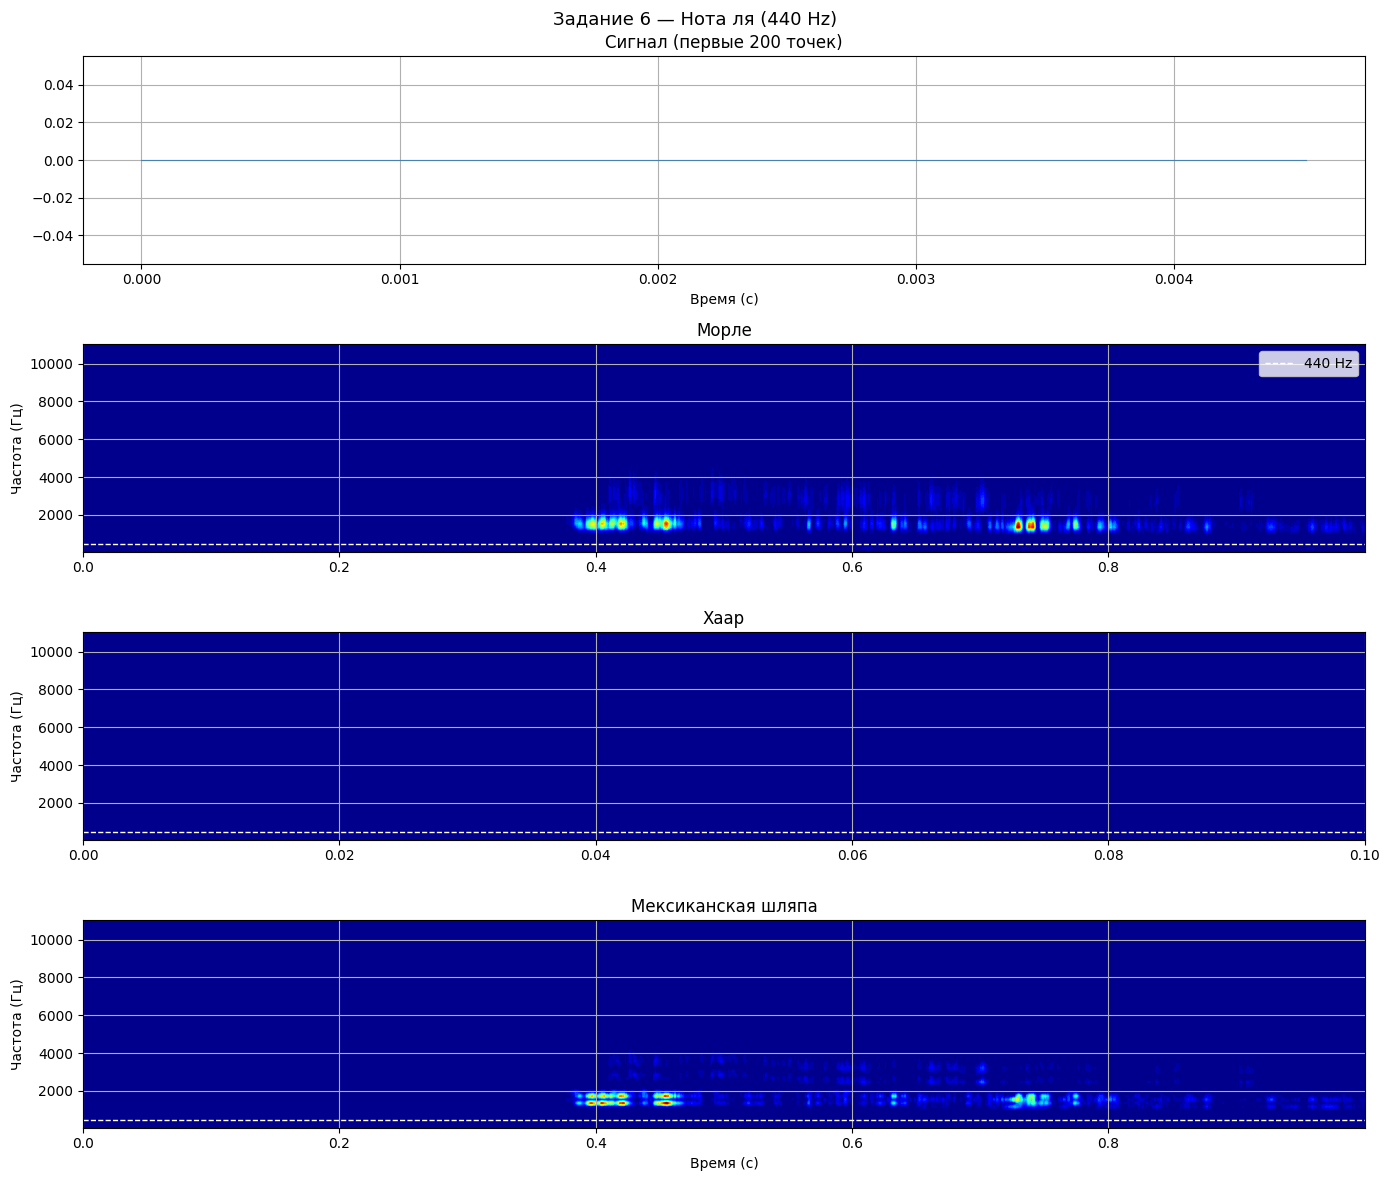

In [7]:
from scipy.fftpack import fft, ifft

# --- загрузка аудио или генерация ноты ля ---
WAV_PATH = 'car_crash.wav'

try:
    sr, audio = wavfile.read(WAV_PATH)
    if audio.ndim > 1:
        audio = audio[:, 0]
    audio = audio.astype(float) / np.max(np.abs(audio))
    n = min(len(audio), sr)
    audio = audio[:n]
    print(f"Файл загружен: sr={sr} Hz, длина={n/sr:.2f} с")
    freqs_audio = np.linspace(50, sr//4, 60)
except (FileNotFoundError, Exception):
    print("Файл не найден — генерируем ноту ля 440 Hz")
    sr    = 8000
    audio = np.sin(2 * np.pi * 440 * np.arange(sr) / sr)
    freqs_audio = np.arange(300, 601, 5, dtype=float)

t_d   = np.arange(len(audio)) / sr
fs_d  = sr

# --- вейвлеты ---
wav_time = np.arange(-0.05, 0.05, 1/fs_d)
half_wav = len(wav_time) // 2
nconv    = len(audio) + len(wav_time) - 1

def make_morlet(t, f):
    """Вейвлет Морле: гауссова огибающая × комплексная экспонента."""
    s = 5 / (2 * np.pi * f)
    return np.exp(1j * 2*np.pi*f * t) * np.exp(-t**2 / (2*s**2))

def make_mhat(t, f):
    """Мексиканская шляпа с несущей частотой f."""
    s = 12 / (2 * np.pi * f)
    return (1 - t**2/s**2) * np.exp(-t**2 / (2*s**2)) * np.exp(1j * 2*np.pi*f * t)

def make_haar(t, f):
    """Вейвлет Хаара для частоты f."""
    a = 1 / f
    psi = np.zeros_like(t, dtype=complex)
    psi[(t >= -a/2) & (t < 0)]   =  1.0
    psi[(t >= 0)    & (t < a/2)] = -1.0
    return psi

def get_spectrogram(sig, wavelet_fn):
    """Скалограмма через FFT-свёртку."""
    sigX   = fft(sig, nconv)
    tf_map = np.zeros((len(freqs_audio), len(sig)))
    for fi, f in enumerate(freqs_audio):
        wavelet = wavelet_fn(wav_time, f)
        if np.sum(np.abs(wavelet)) > 0:
            wavelet = wavelet / np.linalg.norm(wavelet)
        waveX   = fft(wavelet, nconv)
        convres = ifft(waveX * sigX)
        convres = convres[half_wav : half_wav + len(sig)]
        tf_map[fi, :] = np.abs(convres)**2
    return tf_map

print("Считаем скалограммы...")
tf_morlet = get_spectrogram(audio, make_morlet)
tf_mhat   = get_spectrogram(audio, make_mhat)
tf_haar   = get_spectrogram(audio, make_haar)
print("Готово!")

# --- графики ---
fig, axes = plt.subplots(4, 1, figsize=(14, 12))
fig.suptitle('Задание 6 — Нота ля (440 Hz)', fontsize=13)

axes[0].plot(t_d[:200], audio[:200], color='steelblue', lw=0.8)
axes[0].set_title('Сигнал (первые 200 точек)')
axes[0].set_xlabel('Время (с)')

axes[1].contourf(t_d, freqs_audio, tf_morlet, 40, cmap='jet')
axes[1].axhline(440, color='white', lw=1, linestyle='--', label='440 Hz')
axes[1].set_title('Морле')
axes[1].set_ylabel('Частота (Гц)')
axes[1].legend(loc='upper right')

axes[2].contourf(t_d, freqs_audio, tf_haar, 40, cmap='jet')
axes[2].axhline(440, color='white', lw=1, linestyle='--')
axes[2].set_title('Хаар')
axes[2].set_xlim(0,0.1)
axes[2].set_ylabel('Частота (Гц)')

axes[3].contourf(t_d, freqs_audio, tf_mhat, 40, cmap='jet')
axes[3].axhline(440, color='white', lw=1, linestyle='--')
axes[3].set_title('Мексиканская шляпа')
axes[3].set_ylabel('Частота (Гц)')
axes[3].set_xlabel('Время (с)')

plt.tight_layout()
plt.show()